In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('homeprices_banglore.csv')
df.head()


,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
df.describe()

,area,bedrooms,price
count,20.000000,20.000000,20.000000
mean,1821.450000,2.900000,78.853500
std,864.615794,0.967906,43.761901
min,800.000000,1.000000,32.000000
25%,1173.750000,2.000000,41.500000
50%,1480.500000,3.000000,61.000000
75%,2633.000000,3.250000,106.500000
max,3700.000000,5.000000,167.000000


In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
x= df[['area','bedrooms']]
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state =42)
scaler_x= MinMaxScaler()
scaler_y = MinMaxScaler()
x_scaled_train = scaler_x.fit_transform(x_train)
x_scaled_test = scaler_x.transform(x_test)
y_scaled_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_scaled_test = scaler_y.fit_transform(y_test.values.reshape(-1,1))
x_scaled_train


array([[0.17586207, 0.5       ],
       [0.12758621, 0.25      ],
       [0.68448276, 0.75      ],
       [0.24862069, 0.5       ],
       [0.67931034, 0.5       ],
       [0.13103448, 0.5       ],
       [0.10344828, 0.25      ],
       [0.22068966, 0.5       ],
       [1.        , 1.        ],
       [0.        , 0.        ],
       [0.13793103, 0.25      ],
       [0.06896552, 0.25      ],
       [0.86206897, 0.75      ],
       [0.34482759, 0.5       ],
       [0.5       , 0.5       ],
       [0.6662069 , 0.75      ]])

In [5]:
from tensorflow.keras.optimizers import SGD
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer=SGD(learning_rate=0.01),
    loss='mean_squared_error',metrics = ['mse'])

C:\Users\sssri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
print("\nModel summary:")
print(model.summary())

# Train the model
print("\nTraining model...")
history = model.fit(
    x_scaled_train, 
    y_scaled_train, 
    epochs=200,
    validation_data=(x_scaled_test, y_scaled_test),
    verbose=1
)



Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              55 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

None

Training model...
Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step - loss: 0.2215 - mse: 0.2215 - val_loss: 0.2363 - val_mse: 0.2363
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - loss: 0.2041 - mse: 0.2041 - val_loss: 0.2231 - val_mse: 0.2231
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1885 - mse: 0.1885 - val_loss: 0.2111 - val_mse: 0.2111
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.1744 - mse: 0.1744 - val_loss: 0.2004 - val_mse: 0.2004
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.1617 - mse: 0.1617 - val_loss: 0.1907 - val_mse: 0.1907
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.1502 - mse: 0.1502 - val_loss: 0.1820 - val_mse: 0.1820
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1399 - mse: 0.1399 - val_loss: 0.1741 - val_mse: 0.1741
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.1305 - mse: 0.1305 - val_loss: 0.1669 - val_mse: 0.1669
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

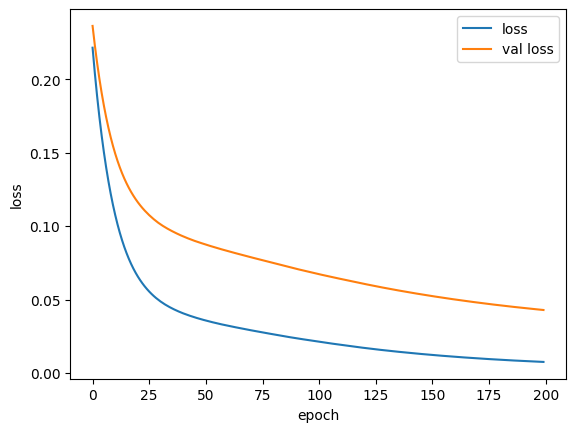

In [7]:
plt.plot(history.history['loss'],label = 'loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

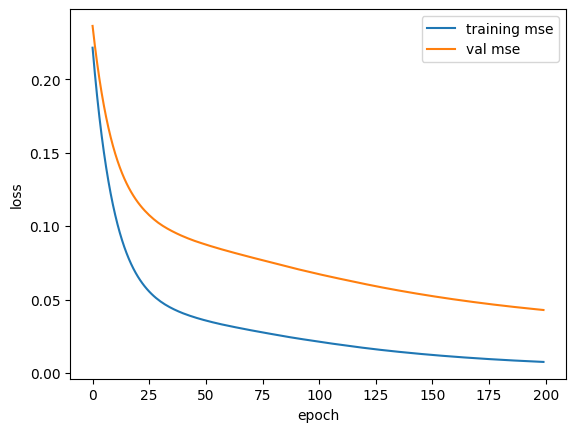

In [8]:
plt.plot(history.history['mse'],label = 'training mse')
plt.plot(history.history['val_mse'],label='val mse')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [9]:
prediction_scaled = model.predict(x_scaled_test)
prediction = scaler_y.inverse_transform(prediction_scaled)
print(prediction[:])
print(y_test.values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[49.81249 ]
 [64.65797 ]
 [52.039303]
 [90.2425  ]]
[ 39.07  60.    42.   120.  ]


In [10]:
import joblib

# Save scalers
joblib.dump(scaler_x, "scaler_x.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")
model.save("house_price_model.h5")
